In [ ]:
from IPython.display import display, HTML

# 1 - Alinhamento técnico da equipe

### Explique, com base no capítulo 1, por que a arquitetura de von Neumann pode elevar o custo energético no treinamento de IA.

A arquitetura de von Neumann apresenta uma limitação estrutural importante para aplicações de Inteligência Artificial: a separação entre a unidade de processamento (ULA e registradores) e a memória principal (RAM), que se comunicam por meio de um barramento.

Durante o treinamento de modelos de IA, são realizadas inúmeras operações matemáticas simples, como multiplicações e somas entre entradas e pesos. No entanto, devido a essa arquitetura, cada operação exige um ciclo repetitivo: primeiro os dados são buscados na memória, depois são transferidos até a unidade de processamento, onde ocorre o cálculo, e em seguida o resultado precisa ser enviado de volta para a memória.

Esse processo gera um grande volume de movimentação de dados. O problema é que o custo energético dessa movimentação é muito maior do que o custo do próprio cálculo. Assim, mesmo que as operações matemáticas sejam simples, o sistema consome muita energia apenas para transportar informações.

Esse fenômeno é conhecido como gargalo de von Neumann, onde a limitação na comunicação entre memória e processamento reduz a eficiência do sistema. Em aplicações de IA, esse problema se torna ainda mais crítico, pois o grande volume de dados e repetições intensifica o consumo energético.

### Explique por que a multiplicação por soma repetida usada no simulador aumenta a quantidade de operações e pode elevar o consumo total.



No simulador utilizado, a multiplicação não é feita por um circuito específico de hardware, mas sim por meio de somas repetidas. Isso significa que, em vez de realizar a operação em um único passo, o sistema precisa executar várias somas consecutivas para chegar ao mesmo resultado.

Esse comportamento aumenta diretamente a quantidade de operações. Por exemplo, quando o valor de entrada é maior, como no caso de x = 4, o sistema precisa realizar quatro somas para simular uma única multiplicação. Assim, quanto maiores forem os valores envolvidos, maior será o número de ciclos necessários.

Esse aumento de operações impacta diretamente o consumo energético. Cada soma exige acesso aos registradores, uso da ULA e atualização dos valores intermediários. Apesar de cada operação individual ter baixo custo, a repetição contínua faz com que o consumo total cresça rapidamente.

Dessa forma, mesmo operações matemáticas simples podem se tornar energeticamente caras quando implementadas dessa maneira, especialmente em cenários com grande volume de dados, como ocorre no treinamento de modelos de Inteligência Artificial.

### Explique por que o número de forwards executados antes de atingir a saída desejada influencia diretamente o custo final do job.


No simulador, cada forward não representa apenas um cálculo simples, mas sim um ciclo completo de execução envolvendo leitura de dados, processamento e escrita de resultados. Por isso, o número de forwards necessários até atingir a saída correta influencia diretamente o consumo total de energia.

A cada forward, o sistema precisa buscar os valores na memória (como pesos e entradas), realizar os cálculos na ULA e verificar o resultado com base no limiar. Esse processo envolve várias operações e, principalmente, múltiplos acessos à memória RAM.

Além disso, quando o resultado não está correto, é necessário executar a etapa de atualização dos pesos. Isso aumenta ainda mais o custo, pois exige novos cálculos e, principalmente, gravações na memória, que são energeticamente caras.

Como o acesso à RAM é o principal fator de consumo dentro da arquitetura de von Neumann, aumentar o número de forwards significa repetir várias vezes esse ciclo completo de leitura, processamento e escrita. Isso faz com que o consumo energético cresça rapidamente.

Dessa forma, quanto mais rápido o modelo conseguir convergir (ou seja, atingir o resultado desejado com menos forwards), menor será o custo total. Por isso, reduzir o número de forwards é uma das formas mais eficientes de diminuir o consumo energético no treinamento.

### Justifique por que, neste checkpoint, a equipe deve priorizar custo operacional e não apenas a saída final do neurônio.

Neste checkpoint, o foco deixa de ser apenas encontrar a resposta correta e passa a considerar como o sistema chega a esse resultado. Ou seja, não basta que o neurônio acerte a saída (y = d), é necessário analisar o custo energético envolvido nesse processo.

Primeiramente, apenas a acurácia não é suficiente para avaliar a viabilidade de um modelo. Nos testes realizados, todos os jobs conseguiram chegar ao resultado esperado. No entanto, isso não significa que todos são eficientes. Um modelo pode acertar, mas consumir muita energia, o que o torna inviável em aplicações reais, como dispositivos IoT ou sistemas em larga escala.

Além disso, a questão da escalabilidade é fundamental. Em cenários reais, modelos de IA executam milhares ou até milhões de operações. Se um único treinamento já apresenta consumo elevado, como observado em alguns jobs que ultrapassaram o limite de 20.000 pJ, esse custo tende a crescer rapidamente quando o sistema é escalado.

Outro ponto importante é a análise da arquitetura. Neste estágio, o objetivo não é apenas ajustar parâmetros para obter o resultado correto, mas sim identificar onde estão os principais pontos de consumo energético, como o alto custo de acesso à memória e a repetição de operações. Isso permite propor melhorias estruturais mais eficientes.

Dessa forma, um modelo com boa eficiência energética pode ser otimizado ao longo do tempo para melhorar sua precisão. Por outro lado, um modelo que já nasce com alto custo energético pode se tornar inviável antes mesmo de ser utilizado em produção.

# 2 - Simulador Python

Utilizem o arquivo/Colab fornecido e alterem apenas os parâmetros de entrada de cada job. A equipe deve executar os três cenários abaixo e registrar os totais acumulados retornados pelo simulador:


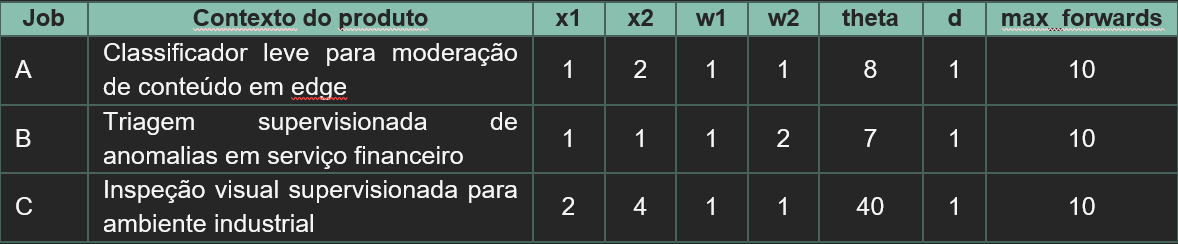

In [ ]:
def ler_mem(mem, endereco, reg, regs, cont, passos, nome):
    regs[reg] = mem[endereco]
    cont["ram"] += 1
    cont["reg"] += 1
    passos.append(f"Ler Mem[{endereco}] e carregar em {reg} -> {nome} = {regs[reg]}")

def gravar_mem(mem, endereco, reg, regs, cont, passos, nome):
    mem[endereco] = regs[reg]
    cont["ram"] += 1
    cont["reg"] += 1
    passos.append(f"Gravar {reg} em Mem[{endereco}] -> {nome} = {mem[endereco]}")

def zerar_reg(reg, regs, cont, passos):
    regs[reg] = 0
    cont["reg"] += 1
    passos.append(f"Zerar {reg} -> {reg} = 0")

def copiar_reg(origem, destino, regs, cont, passos, nome):
    regs[destino] = regs[origem]
    cont["reg"] += 2
    passos.append(f"Copiar {origem} para {destino} -> {nome} = {regs[destino]}")

def ula_add(destino, reg_a, reg_b, regs, cont, passos, descricao):
    a = regs[reg_a]
    b = regs[reg_b]
    regs[destino] = a + b
    cont["ula"] += 1
    cont["reg"] += 3
    passos.append(f"ULA: {destino} = {reg_a} + {reg_b} -> {a} + {b} = {regs[destino]} ({descricao})")

def ula_sub(destino, reg_a, reg_b, regs, cont, passos, descricao):
    a = regs[reg_a]
    b = regs[reg_b]
    regs[destino] = a - b
    cont["ula"] += 1
    cont["reg"] += 3
    passos.append(f"ULA: {destino} = {reg_a} - {reg_b} -> {a} - {b} = {regs[destino]} ({descricao})")

def produto_memoria_por_somas(mem, end_valor, nome_valor, end_fator, nome_fator,
                              reg_destino, regs, cont, passos):
    ler_mem(mem, end_valor, "R0", regs, cont, passos, nome_valor)
    ler_mem(mem, end_fator, "R1", regs, cont, passos, nome_fator)

    repeticoes = regs["R1"]
    zerar_reg(reg_destino, regs, cont, passos)

    for _ in range(repeticoes):
        ula_add(reg_destino, reg_destino, "R0", regs, cont, passos, f"{nome_valor}*{nome_fator}")

    passos.append(
        f"Resumo: {nome_valor}*{nome_fator} = {regs[reg_destino]} "
        f"(obtido com {repeticoes} soma(s))"
    )

def produto_reg_por_memoria(mem, reg_valor, nome_valor, end_fator, nome_fator,
                            reg_destino, regs, cont, passos):
    ler_mem(mem, end_fator, "R1", regs, cont, passos, nome_fator)

    repeticoes = regs["R1"]
    zerar_reg(reg_destino, regs, cont, passos)

    for _ in range(repeticoes):
        ula_add(reg_destino, reg_destino, reg_valor, regs, cont, passos, f"{nome_valor}*{nome_fator}")

    passos.append(
        f"Resumo: {nome_valor}*{nome_fator} = {regs[reg_destino]} "
        f"(obtido com {repeticoes} soma(s))"
    )

def executar_forward(mem):
    regs = {"R0": 0, "R1": 0, "R2": 0, "R3": 0}
    cont = {"ram": 0, "reg": 0, "ula": 0}
    passos = []

    # termo1 = w1 * x1
    produto_memoria_por_somas(mem, 2, "w1", 0, "x1", "R2", regs, cont, passos)
    copiar_reg("R2", "R3", regs, cont, passos, "termo1")

    # termo2 = w2 * x2
    produto_memoria_por_somas(mem, 3, "w2", 1, "x2", "R2", regs, cont, passos)

    # soma dos termos: z = termo1 + termo2
    ula_add("R2", "R3", "R2", regs, cont, passos, "z = (w1*x1) + (w2*x2)")
    gravar_mem(mem, 6, "R2", regs, cont, passos, "z")

    # comparação com o limiar
    ler_mem(mem, 4, "R1", regs, cont, passos, "theta")
    ula_sub("R2", "R2", "R1", regs, cont, passos, "z - theta")

    y = 1 if regs["R2"] >= 0 else 0
    regs["R0"] = y
    cont["reg"] += 1
    passos.append(f"Como o resultado é {'não negativo' if y == 1 else 'negativo'}, definir y = {y}")
    gravar_mem(mem, 7, "R0", regs, cont, passos, "y")

    return mem[6], mem[7], cont, passos


def executar_atualizacao(mem):
    regs = {"R0": 0, "R1": 0, "R2": 0, "R3": 0}
    cont = {"ram": 0, "reg": 0, "ula": 0}
    passos = []

    # erro = d - y
    ler_mem(mem, 5, "R0", regs, cont, passos, "d")
    ler_mem(mem, 7, "R1", regs, cont, passos, "y")
    ula_sub("R2", "R0", "R1", regs, cont, passos, "erro = d - y")
    gravar_mem(mem, 8, "R2", regs, cont, passos, "erro")

    # novo w1 = w1 + erro*x1
    ler_mem(mem, 2, "R0", regs, cont, passos, "w1")
    produto_reg_por_memoria(mem, "R2", "erro", 0, "x1", "R3", regs, cont, passos)
    ula_add("R0", "R0", "R3", regs, cont, passos, "novo w1 = w1 + erro*x1")
    gravar_mem(mem, 2, "R0", regs, cont, passos, "w1 atualizado")

    # novo w2 = w2 + erro*x2
    ler_mem(mem, 3, "R0", regs, cont, passos, "w2")
    produto_reg_por_memoria(mem, "R2", "erro", 1, "x2", "R3", regs, cont, passos)
    ula_add("R0", "R0", "R3", regs, cont, passos, "novo w2 = w2 + erro*x2")
    gravar_mem(mem, 3, "R0", regs, cont, passos, "w2 atualizado")

    return mem[8], mem[2], mem[3], cont, passos


def simular_neuronio(x1, x2, w1, w2, theta, d, max_forwards=10):
    if x1 < 0 or x2 < 0:
        raise ValueError("x1 e x2 devem ser inteiros não negativos.")

    if d not in (0, 1):
        raise ValueError("d deve ser 0 ou 1.")

    mem = [0] * 9
    mem[0] = x1
    mem[1] = x2
    mem[2] = w1
    mem[3] = w2
    mem[4] = theta
    mem[5] = d

    total_ram = 0
    total_reg = 0
    total_ula = 0

    historico = []

    print("\n" + "=" * 90)
    print("SIMULAÇÃO DE 1 NEURÔNIO NO ESTILO DATAPATH")
    print("=" * 90)
    print(f"x1 = {x1}")
    print(f"x2 = {x2}")
    print(f"w1 inicial = {w1}")
    print(f"w2 inicial = {w2}")
    print(f"theta = {theta}")
    print(f"d = {d}")
    print(f"max_forwards = {max_forwards}")

    for ciclo in range(1, max_forwards + 1):
        print("\n" + "-" * 90)
        print(f"FORWARD {ciclo}")
        print("-" * 90)

        z, y, cont_f, passos_f = executar_forward(mem)

        for linha in passos_f:
            print(linha)

        total_ram += cont_f["ram"]
        total_reg += cont_f["reg"]
        total_ula += cont_f["ula"]

        historico.append({
            "forward": ciclo,
            "w1": mem[2],
            "w2": mem[3],
            "z": z,
            "y": y
        })

        print(f"\nResumo do forward {ciclo}: z = {z}, y = {y}")
        print(f"RAM = {cont_f['ram']} | Registradores = {cont_f['reg']} | ULA = {cont_f['ula']}")

        # Se a saída já for a desejada, para a simulação
        if y == d:
            print("\nSaída correta encontrada. Encerrando a simulação.")
            break

        print("\n" + "-" * 90)
        print("ATUALIZAÇÃO")
        print("-" * 90)

        erro, novo_w1, novo_w2, cont_u, passos_u = executar_atualizacao(mem)

        for linha in passos_u:
            print(linha)

        total_ram += cont_u["ram"]
        total_reg += cont_u["reg"]
        total_ula += cont_u["ula"]

        print(f"\nResumo da atualização: erro = {erro}, w1 = {novo_w1}, w2 = {novo_w2}")
        print(f"RAM = {cont_u['ram']} | Registradores = {cont_u['reg']} | ULA = {cont_u['ula']}")

    print("\n" + "=" * 90)
    print("RESUMO FINAL")
    print("=" * 90)
    print(f"{'Forward':<10}{'w1':>8}{'w2':>8}{'z':>8}{'y':>8}")
    print("-" * 42)
    for item in historico:
        print(f"{item['forward']:<10}{item['w1']:>8}{item['w2']:>8}{item['z']:>8}{item['y']:>8}")

    print("\nTotais acumulados:")
    print(f"RAM = {total_ram}")
    print(f"Registradores = {total_reg}")
    print(f"ULA = {total_ula}")
    return total_ram, total_reg, total_ula, historico

## Job A - Classificador leve para moderação de conteúdo em edge

In [ ]:
#Camada de Input
x1 = 1
x2 = 2
w1 = 1
w2 = 1
theta = 8
d = 1
max_forwards = 10

In [ ]:
#Camada de Output
ram, registradores, ula, historico = simular_neuronio(
    x1, x2, w1, w2, theta, d, max_forwards
)


SIMULAÇÃO DE 1 NEURÔNIO NO ESTILO DATAPATH
x1 = 1
x2 = 2
w1 inicial = 1
w2 inicial = 1
theta = 8
d = 1
max_forwards = 10

------------------------------------------------------------------------------------------
FORWARD 1
------------------------------------------------------------------------------------------
Ler Mem[2] e carregar em R0 -> w1 = 1
Ler Mem[0] e carregar em R1 -> x1 = 1
Zerar R2 -> R2 = 0
ULA: R2 = R2 + R0 -> 0 + 1 = 1 (w1*x1)
Resumo: w1*x1 = 1 (obtido com 1 soma(s))
Copiar R2 para R3 -> termo1 = 1
Ler Mem[3] e carregar em R0 -> w2 = 1
Ler Mem[1] e carregar em R1 -> x2 = 2
Zerar R2 -> R2 = 0
ULA: R2 = R2 + R0 -> 0 + 1 = 1 (w2*x2)
ULA: R2 = R2 + R0 -> 1 + 1 = 2 (w2*x2)
Resumo: w2*x2 = 2 (obtido com 2 soma(s))
ULA: R2 = R3 + R2 -> 1 + 2 = 3 (z = (w1*x1) + (w2*x2))
Gravar R2 em Mem[6] -> z = 3
Ler Mem[4] e carregar em R1 -> theta = 8
ULA: R2 = R2 - R1 -> 3 - 8 = -5 (z - theta)
Como o resultado é negativo, definir y = 0
Gravar R0 em Mem[7] -> y = 0

Resumo do forward 1: z

In [ ]:
def conta(ram, registradores, ula):
  energia_total = (640 * ram) + (5 * registradores) + (10 * ula)
  orçamento = 20000.000 # Alterado para float para consistência

  # Formatar o orçamento para '20.000'
  orçamento_formatado = f"{int(orçamento):,d}".replace(',', '.')
  energia_formatada = f"{int(energia_total):,d}".replace(',', '.')

  if orçamento >= energia_total:
    print(f"O orçamento de {orçamento_formatado} pJ é suficiente. Energia total = {energia_formatada} pJ")
  else:
    estouro_valor = energia_total - orçamento
    estouro_formatado = f"{int(estouro_valor):,d}".replace(',', '.')
    print(f"O orçamento de {orçamento_formatado} pJ é insuficiente. Energia total = {energia_formatada} pJ. Estourou o orçamento em {estouro_formatado} pJ.")

conta(ram, registradores, ula)

O orçamento de 20.000 pJ é suficiente. Energia total = 15.295 pJ


## Job B - Triagem supervisionada de anomalias em serviço financeiro


In [ ]:
#Camada de Input
x1 = 1
x2 = 1
w1 = 1
w2 = 2
theta = 7
d = 1
max_forwards = 10

In [ ]:
#Camada de Output
ram, registradores, ula, historico = simular_neuronio(
    x1, x2, w1, w2, theta, d, max_forwards
)


SIMULAÇÃO DE 1 NEURÔNIO NO ESTILO DATAPATH
x1 = 1
x2 = 1
w1 inicial = 1
w2 inicial = 2
theta = 7
d = 1
max_forwards = 10

------------------------------------------------------------------------------------------
FORWARD 1
------------------------------------------------------------------------------------------
Ler Mem[2] e carregar em R0 -> w1 = 1
Ler Mem[0] e carregar em R1 -> x1 = 1
Zerar R2 -> R2 = 0
ULA: R2 = R2 + R0 -> 0 + 1 = 1 (w1*x1)
Resumo: w1*x1 = 1 (obtido com 1 soma(s))
Copiar R2 para R3 -> termo1 = 1
Ler Mem[3] e carregar em R0 -> w2 = 2
Ler Mem[1] e carregar em R1 -> x2 = 1
Zerar R2 -> R2 = 0
ULA: R2 = R2 + R0 -> 0 + 2 = 2 (w2*x2)
Resumo: w2*x2 = 2 (obtido com 1 soma(s))
ULA: R2 = R3 + R2 -> 1 + 2 = 3 (z = (w1*x1) + (w2*x2))
Gravar R2 em Mem[6] -> z = 3
Ler Mem[4] e carregar em R1 -> theta = 7
ULA: R2 = R2 - R1 -> 3 - 7 = -4 (z - theta)
Como o resultado é negativo, definir y = 0
Gravar R0 em Mem[7] -> y = 0

Resumo do forward 1: z = 3, y = 0
RAM = 7 | Registradores = 2

In [ ]:
def conta(ram, registradores, ula):
  energia_total = (640 * ram) + (5 * registradores) + (10 * ula)
  orçamento = 20000.000 # Alterado para float para consistência

  # Formatar o orçamento para '20.000'
  orçamento_formatado = f"{int(orçamento):,d}".replace(',', '.')
  energia_formatada = f"{int(energia_total):,d}".replace(',', '.')

  if orçamento >= energia_total:
    print(f"O orçamento de {orçamento_formatado} pJ é suficiente. Energia total = {energia_formatada} pJ")
  else:
    estouro_valor = energia_total - orçamento
    estouro_formatado = f"{int(estouro_valor):,d}".replace(',', '.')
    print(f"O orçamento de {orçamento_formatado} pJ é insuficiente. Energia total = {energia_formatada} pJ. Estourou o orçamento em {estouro_formatado} pJ.")

conta(ram, registradores, ula)

O orçamento de 20.000 pJ é insuficiente. Energia total = 25.800 pJ. Estourou o orçamento em 5.800 pJ.


## Job C - Inspeção visual supervisionada para ambiente industrial

In [ ]:
#Camada de Input
x1 = 2
x2 = 4
w1 = 1
w2 = 1
theta = 40
d = 1
max_forwards = 10

In [ ]:
#Camada de Output
ram, registradores, ula, historico = simular_neuronio(
    x1, x2, w1, w2, theta, d, max_forwards
)


SIMULAÇÃO DE 1 NEURÔNIO NO ESTILO DATAPATH
x1 = 2
x2 = 4
w1 inicial = 1
w2 inicial = 1
theta = 40
d = 1
max_forwards = 10

------------------------------------------------------------------------------------------
FORWARD 1
------------------------------------------------------------------------------------------
Ler Mem[2] e carregar em R0 -> w1 = 1
Ler Mem[0] e carregar em R1 -> x1 = 2
Zerar R2 -> R2 = 0
ULA: R2 = R2 + R0 -> 0 + 1 = 1 (w1*x1)
ULA: R2 = R2 + R0 -> 1 + 1 = 2 (w1*x1)
Resumo: w1*x1 = 2 (obtido com 2 soma(s))
Copiar R2 para R3 -> termo1 = 2
Ler Mem[3] e carregar em R0 -> w2 = 1
Ler Mem[1] e carregar em R1 -> x2 = 4
Zerar R2 -> R2 = 0
ULA: R2 = R2 + R0 -> 0 + 1 = 1 (w2*x2)
ULA: R2 = R2 + R0 -> 1 + 1 = 2 (w2*x2)
ULA: R2 = R2 + R0 -> 2 + 1 = 3 (w2*x2)
ULA: R2 = R2 + R0 -> 3 + 1 = 4 (w2*x2)
Resumo: w2*x2 = 4 (obtido com 4 soma(s))
ULA: R2 = R3 + R2 -> 2 + 4 = 6 (z = (w1*x1) + (w2*x2))
Gravar R2 em Mem[6] -> z = 6
Ler Mem[4] e carregar em R1 -> theta = 40
ULA: R2 = R2 - R1 ->

In [ ]:
def conta(ram, registradores, ula):
  energia_total = (640 * ram) + (5 * registradores) + (10 * ula)
  orçamento = 20000.000 # Alterado para float para consistência

  # Formatar o orçamento para '20.000'
  orçamento_formatado = f"{int(orçamento):,d}".replace(',', '.')
  energia_formatada = f"{int(energia_total):,d}".replace(',', '.')

  if orçamento >= energia_total:
    print(f"O orçamento de {orçamento_formatado} pJ é suficiente. Energia total = {energia_formatada} pJ")
  else:
    estouro_valor = energia_total - orçamento
    estouro_formatado = f"{int(estouro_valor):,d}".replace(',', '.')
    print(f"O orçamento de {orçamento_formatado} pJ é insuficiente. Energia total = {energia_formatada} pJ. Estourou o orçamento em {estouro_formatado} pJ.")

conta(ram, registradores, ula)

O orçamento de 20.000 pJ é insuficiente. Energia total = 26.300 pJ. Estourou o orçamento em 6.300 pJ.


## Tabela

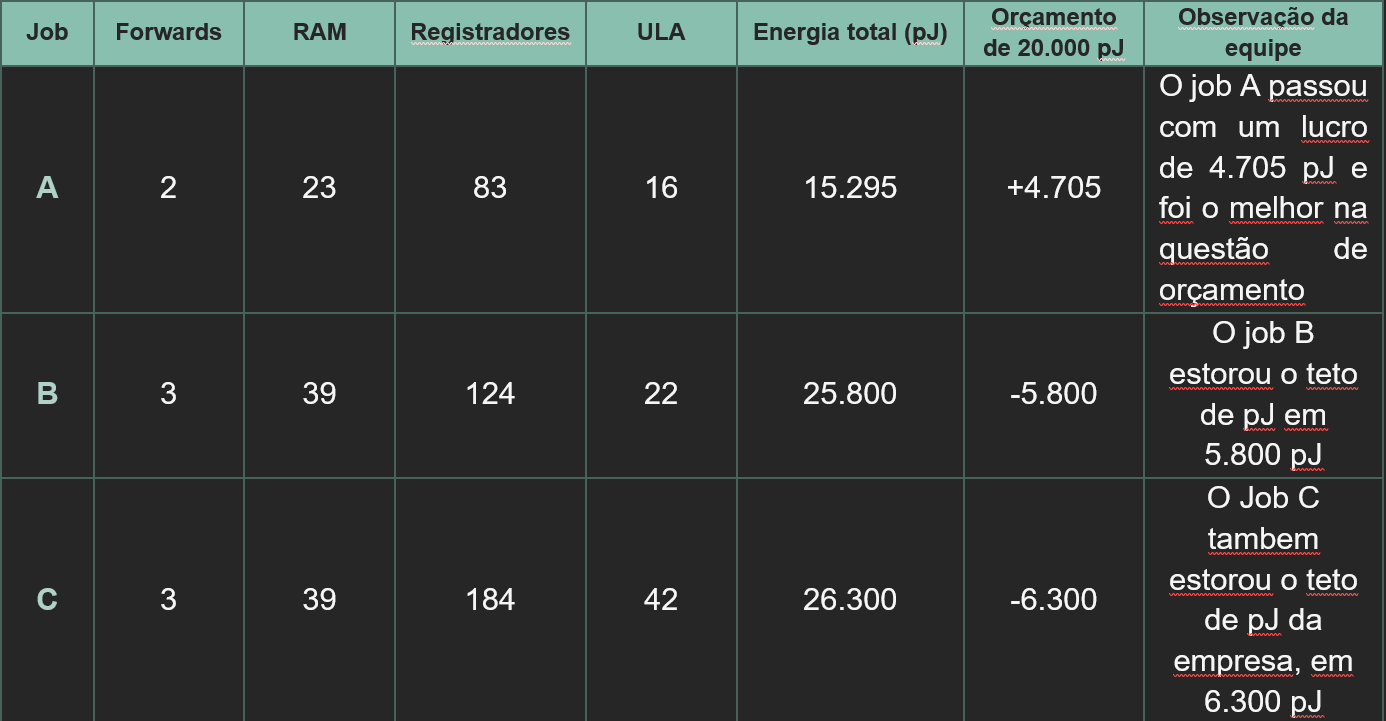

# 3 - Comparativo técnico e leitura de infraestrutura

### Ordenem os três jobs do menor para o maior consumo energético.



Segue abaixo a lista dos Jobs:


1.   Job A - 15.295 pJ
2.   Job B - 25.800 pJ
3.   Job A - 26.300 pJ

Sendo Job A aquele com o menor valor energetico


### Indiquem quais jobs cabem no orçamento máximo de 20.000 pJ por execução e quais exigem revisão antes de escalar.


✅ Job A: dentro do orçamento (+4.705 pJ de folga)

❌ Job B: excede (-5.800 pJ)

❌ Job C: excede (-6.300 pJ)

📌 Conclusão:

Apenas o Job A é viável para escalar.

Os Jobs B e C precisam de otimização antes.

### Expliquem qual combinação de fatores parece elevar mais o custo no simulador: número de forwards, valores de entrada (x1 e x2), limiar theta ou pesos iniciais.



                                            | Fator         | A  | B   | C   |
                                            | ------------- | -- | --- | --- |
                                            | Forwards      | 2  | 3   | 3   |
                                            | RAM           | 23 | 39  | 39  |
                                            | Registradores | 83 | 124 | 184 |
                                            | ULA           | 16 | 22  | 42  |





<font color="Red">Forwards:</font> Aumenta o custo (A tem 2, B e C têm 3 → custo sobe)

<font color="Violet ">RAM:</font> Grande impacto (23 → 39 já aumenta bastante energia)

<font color="Pink">Registradores::</font>
Um dos maiores vilões (cresce muito de B → C)

<font color="Yellow">ULA:</font> Também pesa, principalmente no Job C (42 é alto)

<font color="Orange">Entradas (x1, x2), pesos e theta:</font> Eles não consomem energia diretamente, mas:


*   Influenciam o número de operações
*   Podem aumentar uso de ULA e registradores

<font color="Green">O custo é mais impactado por:</font>


Movimentação de dados (RAM + registradores) + número de operações (ULA + forwards)


### Apontem, com linguagem técnica simples, qual é o principal gargalo observado: RAM, registradores, ULA ou a combinação entre movimento de dados e repetição de operações.

O principal gargalo do sistema não está em um único componente, mas na combinação entre movimentação de dados e repetição de operações. O acesso à RAM é o fator mais crítico, pois tem um custo energético muito alto (640 pJ por acesso), tornando cada leitura ou escrita cara.

Além disso, mais forwards aumentam o uso da ULA e dos registradores, que mesmo sendo mais baratos, elevam o consumo quando usados repetidamente.

Assim, o problema central é a soma de acessos frequentes à memória com múltiplas execuções de cálculos, o que amplifica significativamente o custo energético total.

# 4 - Recomendação executiva da equipe

Produzam um mini relatório executivo como se ele fosse enviado ao gerente de operações da NeuroScale AI. O texto deve ser objetivo, técnico e tomar uma decisão. Estruturem o documento final com os quatro blocos abaixo:

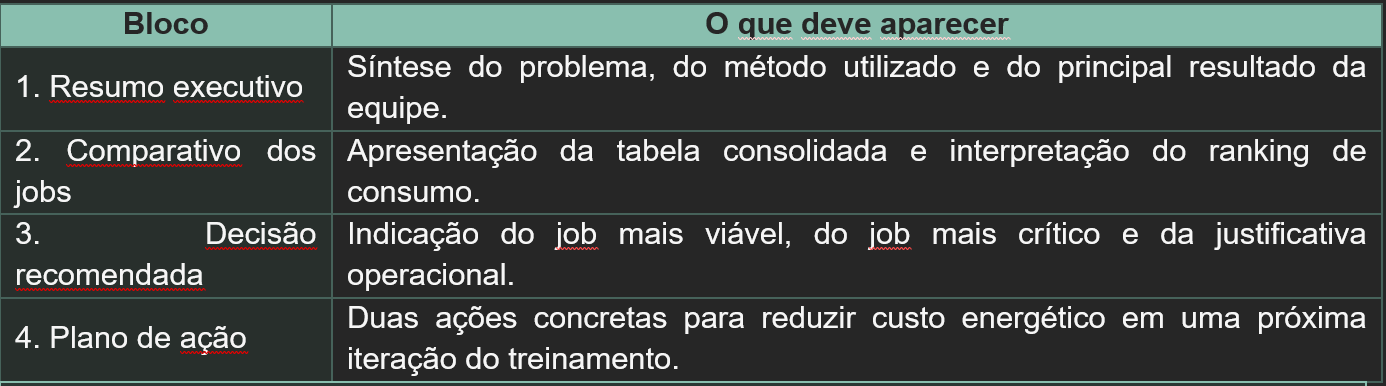

In [ ]:
from IPython.display import display, HTML

relatorio_html = """
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6; color: #333; max-width: 950px; margin: auto; border: 1px solid #e1e4e8; padding: 30px; border-radius: 10px; background-color: #ffffff; box-shadow: 0 4px 8px rgba(0,0,0,0.05);">

    <div style="text-align: center; margin-bottom: 30px;">
        <h2 style="color: #2c3e50; margin-bottom: 5px;">SPRINT 4: Relatório Executivo de Eficiência Energética</h2>
        <p style="color: #7f8c8d; font-size: 14px; margin-top: 0;">Análise de viabilidade para arquitetura Datapath (Orçamento Máximo: 20.000 pJ)</p>
    </div>

    <h3 style="color: #2980b9; border-bottom: 2px solid #ecf0f1; padding-bottom: 5px;">1. Resumo Executivo</h3>
    <ul style="list-style-type: none; padding-left: 0;">
        <li style="margin-bottom: 10px;">🎯 <strong>O que foi feito:</strong> Avaliamos o consumo energético de um neurônio em três contextos de operação (Jobs A, B e C) para validar a escalabilidade do modelo frente a uma restrição de infraestrutura.</li>
        <li style="margin-bottom: 10px;">⚙️ <strong>Como foi feito:</strong> Simulamos a arquitetura baseada em datapath, isolando e precificando o custo de operações de ULA, uso de registradores e leitura/escrita em RAM durante múltiplos ciclos (forwards).</li>
        <li>📊 <strong>Resultado principal:</strong> Identificamos que <strong>apenas o Job A está apto para produção</strong>. Os Jobs B e C ultrapassam o teto orçamentário em até 31%, exigindo refatoração algorítmica e arquitetural antes de qualquer ganho de escala.</li>
    </ul>

    <h3 style="color: #2980b9; border-bottom: 2px solid #ecf0f1; padding-bottom: 5px; margin-top: 30px;">2. Comparativo dos Jobs e Consumo</h3>
    <table style="width: 100%; border-collapse: collapse; margin-bottom: 10px; font-size: 14px;">
        <thead>
            <tr style="background-color: #f8f9fa; color: #2c3e50; text-align: left;">
                <th style="padding: 12px; border-bottom: 2px solid #dee2e6;">Job</th>
                <th style="padding: 12px; border-bottom: 2px solid #dee2e6;">Forwards</th>
                <th style="padding: 12px; border-bottom: 2px solid #dee2e6;">Custo Total (pJ)</th>
                <th style="padding: 12px; border-bottom: 2px solid #dee2e6;">Uso do Orçamento (20k pJ)</th>
                <th style="padding: 12px; border-bottom: 2px solid #dee2e6;">Status</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><strong>A</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">2</td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><strong>15.295</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">
                    <div style="background-color: #e9ecef; border-radius: 4px; width: 100%; height: 16px;">
                        <div style="background-color: #2ecc71; height: 16px; border-radius: 4px; width: 76%;"></div>
                    </div>
                    <small style="color: #555;">76%</small>
                </td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><span style="background-color: #d4edda; color: #155724; padding: 4px 8px; border-radius: 4px; font-weight: bold;">Aprovado</span></td>
            </tr>
            <tr>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><strong>B</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">3</td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><strong>25.800</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">
                    <div style="background-color: #e9ecef; border-radius: 4px; width: 100%; height: 16px;">
                        <div style="background-color: #e74c3c; height: 16px; border-radius: 4px; width: 100%;"></div>
                    </div>
                    <small style="color: #e74c3c; font-weight: bold;">129% (Estouro de 5.8k)</small>
                </td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><span style="background-color: #f8d7da; color: #721c24; padding: 4px 8px; border-radius: 4px; font-weight: bold;">Bloqueado</span></td>
            </tr>
            <tr>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><strong>C</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">3</td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><strong>26.300</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">
                    <div style="background-color: #e9ecef; border-radius: 4px; width: 100%; height: 16px;">
                        <div style="background-color: #e74c3c; height: 16px; border-radius: 4px; width: 100%;"></div>
                    </div>
                    <small style="color: #e74c3c; font-weight: bold;">131% (Estouro de 6.3k)</small>
                </td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><span style="background-color: #f8d7da; color: #721c24; padding: 4px 8px; border-radius: 4px; font-weight: bold;">Bloqueado</span></td>
            </tr>
        </tbody>
    </table>
    <p style="font-size: 14px; color: #555;"><strong>Análise do Gargalo:</strong> O crescimento do custo não é linear. O principal ralo de recursos é a <strong>movimentação de dados</strong>. Os acessos à RAM possuem um custo altíssimo (640 pJ por ciclo). Quando o sistema exige mais <em>forwards</em>, ele multiplica o acesso à RAM e sobrecarrega os registradores, causando o estouro orçamentário visto nos Jobs B e C.</p>

    <h3 style="color: #2980b9; border-bottom: 2px solid #ecf0f1; padding-bottom: 5px; margin-top: 30px;">3. Decisão Arquitetural</h3>
    <ul style="list-style-type: none; padding-left: 0;">
        <li style="margin-bottom: 10px;">🏆 <strong>Melhor Job (Mais eficiente): Job A.</strong> Trabalha com folga de 24% no orçamento, sendo altamente seguro para implantação imediata.</li>
        <li style="margin-bottom: 10px;">⚠️ <strong>Pior Job (Mais caro): Job C.</strong> Apresenta o maior volume de operações lógicas (ULA: 42) e movimentação em registradores (184), impulsionado por entradas complexas que exigem mais repetições.</li>
        <li>💡 <strong>Justificativa Técnica:</strong> A ineficiência não está em um único componente, mas na arquitetura de repetição. Pesos iniciais descalibrados forçam mais ciclos (forwards), o que obriga a ULA a processar novamente e a RAM a ser lida diversas vezes.</li>
    </ul>

    <h3 style="color: #2980b9; border-bottom: 2px solid #ecf0f1; padding-bottom: 5px; margin-top: 30px;">4. Plano de Ação (Redução de Custos)</h3>
    <p>Para viabilizar a operação dos cenários mais complexos (B e C), recomendamos a aplicação imediata de duas frentes de engenharia:</p>
    <div style="display: flex; gap: 20px; margin-top: 15px;">
        <div style="flex: 1; background-color: #f4f6f7; padding: 15px; border-left: 4px solid #3498db; border-radius: 4px;">
            <strong style="color: #2c3e50;">Aprimorar Heurística de Inicialização</strong><br>
            <span style="font-size: 14px; color: #555;">Melhorar a definição dos <strong>pesos iniciais</strong> (Warm Start) para que comecem mais próximos do limiar (theta). <strong>Impacto:</strong> Redução direta do número de <em>forwards</em> necessários para o aprendizado.</span>
        </div>
        <div style="flex: 1; background-color: #f4f6f7; padding: 15px; border-left: 4px solid #3498db; border-radius: 4px;">
            <strong style="color: #2c3e50;">Otimizar Caching de Dados</strong><br>
            <span style="font-size: 14px; color: #555;">Alterar a política de memória para priorizar <strong>registradores</strong> como cache temporário. <strong>Impacto:</strong> Diminuição substancial dos acessos diretos à RAM, contornando o componente de maior custo energético (640 pJ).</span>
        </div>
    </div>

    <h1 style="color: #6c3483; border-bottom: 3px solid #d7bde2; padding-bottom: 10px; margin-top: 40px;">
        ⚛️ Extensão Criativa: Estratégia com Computação Quântica
    </h1>

    <p style="font-size: 15px; color: #555; margin-bottom: 20px;">
        Como diferencial qualitativo, a equipe propõe uma estratégia baseada em
        <strong>Computação Quântica (CQ)</strong> para reduzir o custo energético do
        <strong>Job C</strong>, o mais caro da sprint (26.300 pJ — 131% do orçamento).
    </p>

    <h3 style="color: #6c3483; border-bottom: 2px solid #ecf0f1; padding-bottom: 5px;">
        🔍 Problema identificado no Job C
    </h3>
    <p style="font-size: 14px; color: #555;">
        O Job C possui entradas elevadas (<strong>x1 = 2, x2 = 4</strong>) e limiar alto
        (<strong>theta = 40</strong>), o que força múltiplos <em>forwards</em> antes da
        convergência. Cada <em>forward</em> aciona novos acessos à RAM (640 pJ cada),
        tornando o custo de <strong>movimentação de dados</strong> o principal vilão do orçamento.
        O gargalo está na <strong>etapa de multiplicação e acumulação de pesos (MAC)</strong>
        — operação central de todo neurônio.
    </p>

    <h3 style="color: #6c3483; border-bottom: 2px solid #ecf0f1; padding-bottom: 5px; margin-top: 25px;">
        ⚛️ Proposta: Arquitetura Híbrida Clássico-Quântica
    </h3>
    <p style="font-size: 14px; color: #555;">
        Propõe-se uma arquitetura híbrida onde o <strong>subsistema clássico</strong>
        continua responsável pela orquestração do job, enquanto um
        <strong>co-processador quântico</strong> assume a etapa crítica de multiplicação
        e acumulação dos pesos:
    </p>

    <div style="display: flex; gap: 20px; margin-top: 15px; margin-bottom: 20px;">
        <div style="flex: 1; background-color: #f9f0ff; padding: 15px; border-left: 4px solid #6c3483; border-radius: 4px;">
            <strong style="color: #4a235a;">Etapa otimizada pela CQ: Multiplicação de Pesos (MAC)</strong><br>
            <span style="font-size: 13px; color: #555; margin-top: 8px; display: block;">
                Circuitos de <strong>produto interno quântico</strong> permitem calcular
                <code>w1·x1 + w2·x2</code> em <strong>superposição</strong>, sem
                buscar cada peso sequencialmente na RAM. O resultado é obtido
                com um único colapso de estado quântico, eliminando os ciclos repetitivos
                de leitura/escrita na memória clássica.
            </span>
        </div>
        <div style="flex: 1; background-color: #f9f0ff; padding: 15px; border-left: 4px solid #6c3483; border-radius: 4px;">
            <strong style="color: #4a235a;">Etapa mantida no clássico: Comparação com theta e atualização</strong><br>
            <span style="font-size: 13px; color: #555; margin-top: 8px; display: block;">
                A comparação do resultado com o limiar <strong>theta</strong> e a
                decisão de atualizar os pesos continuam no processador clássico,
                aproveitando a infraestrutura já existente e reduzindo a complexidade
                de implementação quântica.
            </span>
        </div>
    </div>

    <h3 style="color: #6c3483; border-bottom: 2px solid #ecf0f1; padding-bottom: 5px; margin-top: 25px;">
        📉 Impacto estimado no consumo energético
    </h3>
    <table style="width: 100%; border-collapse: collapse; font-size: 14px; margin-bottom: 15px;">
        <thead>
            <tr style="background-color: #f4ecf7; color: #4a235a; text-align: left;">
                <th style="padding: 12px; border-bottom: 2px solid #d7bde2;">Cenário</th>
                <th style="padding: 12px; border-bottom: 2px solid #d7bde2;">Acessos RAM</th>
                <th style="padding: 12px; border-bottom: 2px solid #d7bde2;">Custo Estimado (pJ)</th>
                <th style="padding: 12px; border-bottom: 2px solid #d7bde2;">Status</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">Job C — Arquitetura clássica (atual)</td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">Alto (múltiplos forwards)</td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><strong>26.300 pJ</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">
                    <span style="background-color: #f8d7da; color: #721c24; padding: 4px 8px; border-radius: 4px; font-weight: bold;">Bloqueado</span>
                </td>
            </tr>
            <tr>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">Job C — Arquitetura híbrida CQ (proposta)</td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">Reduzido (MAC em superposição)</td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;"><strong>~14.000 – 17.000 pJ *</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #dee2e6;">
                    <span style="background-color: #d4edda; color: #155724; padding: 4px 8px; border-radius: 4px; font-weight: bold;">Viável</span>
                </td>
            </tr>
        </tbody>
    </table>
    <p style="font-size: 12px; color: #888;">
        * Estimativa baseada na eliminação dos acessos repetidos à RAM durante a etapa MAC.
        O custo residual inclui leitura inicial dos dados e operações de controle clássico.
    </p>

    <h3 style="color: #6c3483; border-bottom: 2px solid #ecf0f1; padding-bottom: 5px; margin-top: 25px;">
        ✅ Conclusão
    </h3>
    <p style="font-size: 14px; color: #555;">
        A adoção de um <strong>co-processador quântico focado na etapa MAC</strong> representa
        a otimização mais cirúrgica possível para este cenário. Ao eliminar os acessos
        repetitivos à RAM durante a multiplicação de pesos, a arquitetura híbrida tem potencial
        de trazer o <strong>Job C para dentro do orçamento de 20.000 pJ</strong>, sem exigir
        a substituição completa da infraestrutura clássica existente.
    </p>

</div>
"""

display(HTML(relatorio_html))
